# Capstone --- Combining Predictive Techniques

**Team member:** Ellis Madrigal
**Course:** BANA 620 --- Predictive Analytics & Data Mining  

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Pedantic design specifications
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#EF4123', '#334869', '#002A4E'])
plt.style.use('ggplot')

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## 1. Problem Statement

LendingClub is an online P2P lending platform. Though it is always risky to lend money, because LendingClub operates outside of the standard banking system, borrower default can have a larger effect on their own financial health. 

The company assigns a letter grade to all loan applications based on their proprietary risk model. A, B, and C are prime loans with better interest rates. D, E, F, and G are subprime loans with higher interest rates.

In this exercise, I am taking on the role of an employee creating a "second-opinion model." The model's job is akin to cross-validation for LendingClub's existing proprietary grading model. The target variable will be a new variable, "risky_grade," that signifies a D, E, F, or G loan. I will create four predictive models, compare their results, and recommend which is fit for production. 

## Load the raw data

In [2]:
loans = pd.read_csv('lending_club_raw.csv')
print('Shape:', loans.shape)
loans.head()

Shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


### Inspection: dtypes and missingness

Use the output below to plan your cleaning. Look for:
- columns stored as strings that should be numeric
- columns with heavy missingness

In [3]:
print(loans.dtypes.value_counts())
print()
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(1))

int64      25
float64    17
str        13
Name: count, dtype: int64

verification_income_joint           85.4
annual_income_joint                 85.0
debt_to_income_joint                85.0
months_since_90d_late               77.1
months_since_last_delinq            56.6
months_since_last_credit_inquiry    12.7
emp_title                            8.3
emp_length                           8.2
num_accounts_120d_past_due           3.2
debt_to_income                       0.2
dtype: float64


## 2. Exploratory Data Analysis

**Required:** at least three visualizations, each with a one- or two-sentence caption.

In [4]:
# target engineering
loans['risky_grade'] = loans['grade'].isin(['D','E','F','G']).astype(int)

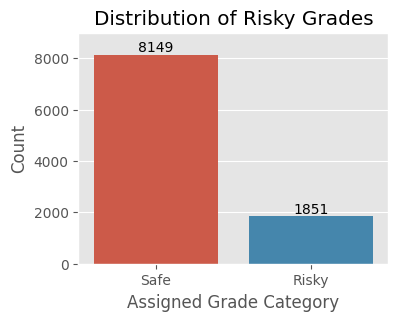

In [5]:
# TODO: visualization 1 --- target distribution
plt.figure(figsize=(4,3))
plt.title('Distribution of Risky Grades')
plt.xlabel('Assigned Grade Category')
plt.ylabel('Count')
plt.ylim(0, 9000)
ax = sns.countplot(data=loans, x='risky_grade', hue='risky_grade', legend=False)
ax.set_xticks([0,1], labels=['Safe','Risky'])
for container in ax.containers:
    ax.bar_label(container)
plt.show()

There is a significant class imbalance in the dataset; the target class comprises ~18.5% of the total dataset. As further visualizations will show, there are also significant outliers. Both of these issues will need to be accounted for in the modeling process.

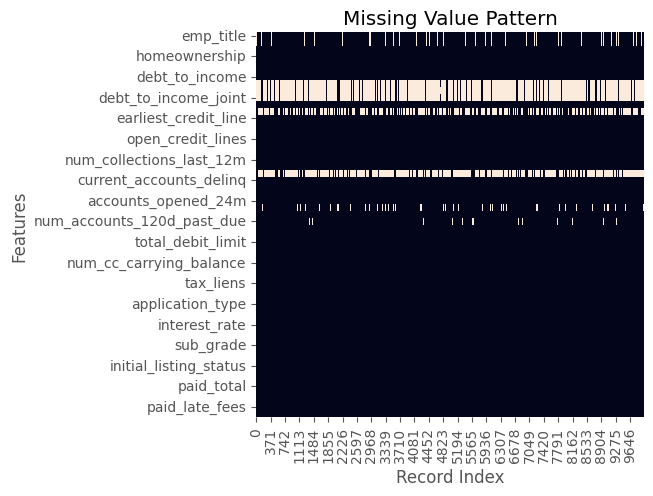

                         feature  percent_missing
       verification_income_joint            85.45
             annual_income_joint            85.05
            debt_to_income_joint            85.05
           months_since_90d_late            77.15
        months_since_last_delinq            56.58
months_since_last_credit_inquiry            12.71
                       emp_title             8.33
                      emp_length             8.17
      num_accounts_120d_past_due             3.18
                  debt_to_income             0.24


In [6]:
plt.figure(figsize=(5,5))
sns.heatmap(loans.isna().transpose(), cbar=False)
plt.title("Missing Value Pattern")
plt.xlabel("Record Index")
plt.ylabel("Features")
plt.show()

# add summary table
missingpct = (loans.isna().sum()) * 100 / len(loans)
missingpct_table = pd.DataFrame({
    'feature': loans.columns,
    'percent_missing': missingpct.values
})
missingpct_table = missingpct_table.sort_values('percent_missing', ascending=False, ignore_index=True)
print(missingpct_table[missingpct_table['percent_missing'] > 0].to_string(index=False))

Though the dataset has significant missingness, the majority of it makes sense. For example, "joint" features are mostly empty, because the majority of applications were filed as individuals, and unemployed applicants have empty values in `emp_title` and `emp_length`. The modeling strategy will be deciding what features should be completely dropped, and what features can be engineered to be represented in a different way.

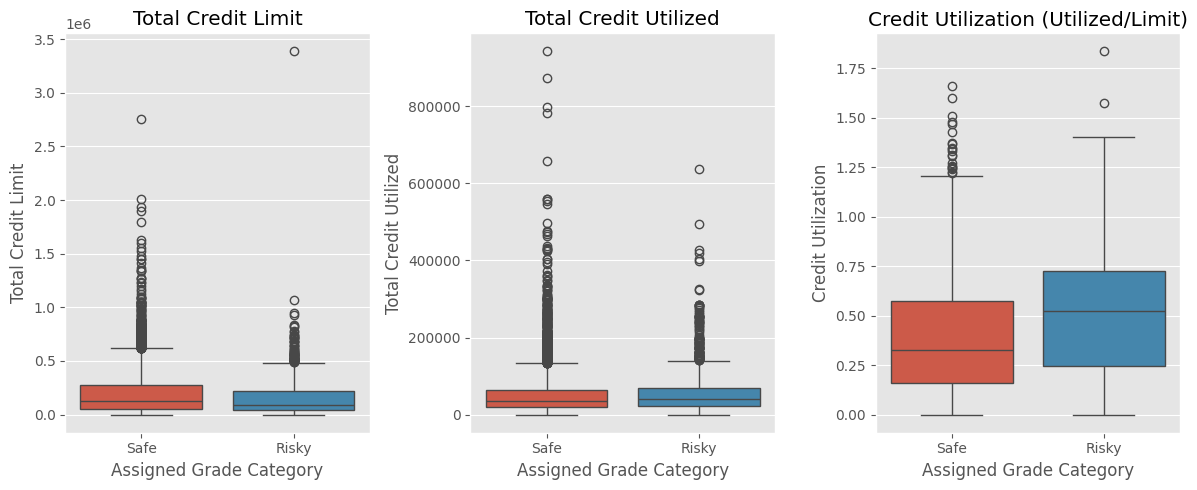

mean                                           \
            credit_utilization total_credit_limit total_credit_utilized   
risky_grade                                                               
0                     0.380517      191111.703767          50469.786354   
1                     0.502397      150563.495408          53599.320367   

                        median                                           
            credit_utilization total_credit_limit total_credit_utilized  
risky_grade                                                              
0                     0.327703           122484.0               36063.0  
1                     0.524941            88016.0               39935.0

In [7]:
loans['credit_utilization'] = np.where(loans['total_credit_limit'] > 0, (loans['total_credit_utilized'] / loans['total_credit_limit']), 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Total Credit Limit
sns.boxplot(data=loans, x='risky_grade', y='total_credit_limit', ax=axes[0], hue='risky_grade', legend=False)
axes[0].set_title('Total Credit Limit')
axes[0].set_xlabel('Assigned Grade Category')
axes[0].set_ylabel('Total Credit Limit')
axes[0].set_xticks([0,1], labels=['Safe','Risky'])

sns.boxplot(data=loans, x='risky_grade', y='total_credit_utilized', ax=axes[1], hue='risky_grade', legend=False)
axes[1].set_title('Total Credit Utilized')
axes[1].set_xlabel('Assigned Grade Category')
axes[1].set_ylabel('Total Credit Utilized')
axes[1].set_xticks([0,1], labels=['Safe','Risky'])

sns.boxplot(data=loans, x='risky_grade', y='credit_utilization', ax=axes[2], hue='risky_grade', legend=False)
axes[2].set_title('Credit Utilization (Utilized/Limit)')
axes[2].set_xlabel('Assigned Grade Category')
axes[2].set_ylabel('Credit Utilization')
axes[2].set_xticks([0,1], labels=['Safe','Risky'])

plt.tight_layout()
plt.show()

pd.pivot_table(loans, index='risky_grade', values=['total_credit_limit', 'total_credit_utilized', 'credit_utilization'], aggfunc=['mean', 'median'])

Because there are significantly more records in the healthy grade versus the risky grade class, the most effective visualizations directly compare the spread and centrality for each class. However, the significant volume of outliers make visualizing, even with boxplots, tricky. 

To address this issue, I created the factor `credit utilization`, which divides `total_credit_limit` by `total_credit_utilized`. The credit utilization feature is one of the few numerical features with a meaningful difference between "safe" and "risky" applications; the median application with a risky grade has ~52.5% of their total credit currently utilized, compared to safe grade's median ~32.8%.

## 3. Data Cleaning

### 3.1 Drop the data-leakage columns

| Removal Category | Features removed | Explanation |
| --- | --- | --- |
| Target variable multicollinarity | `grade`, `sub_grade`, `interest_rate` | Features are either the source that `risky_grade` is derived from, or are drilled-down details or results from the `grade` column. Keeping them in would introduce multicollinarity with the dependent variable. |
| Derived from removed source | `installment` | Because `installment` is derived, in part, from `interest_rate`, which has to be removed, `installment` must also be removed. |
| Post-approval | `loan_amount`, `term`, `issue_month`, `loan_status`, `initial_listing_status`, `disbursement_method` | These features describe the outcome of the first model. Because my model must only consider information included in the application, these attributes need to be removed. |
| Payment history | `balance`, `paid_total`, `paid_principal`, `paid_interest`, `paid_late_fees` | Similar to above, these features record the loan's current balance and payment history. They need to be removed in order to only predict based on the initial application. |

In [8]:
# Explicit leakage columns --- listed in the instructions PDF.
LEAKAGE_COLUMNS = [
    'grade',                  # target is derived from this column
    'sub_grade',              # finer version of grade; same leakage
    'interest_rate',          # set by Lending Club based on grade
    'installment',            # derived from loan_amount, term, interest_rate
    'loan_status',            # post-origination outcome
    'initial_listing_status', # only known after Lending Club approves the loan
    'disbursement_method',    # only known after approval
    'balance',                # post-origination balance
    'paid_total',             # post-origination payment outcome
    'paid_principal',         # post-origination payment outcome
    'paid_interest',          # post-origination payment outcome
    'paid_late_fees',         # post-origination payment outcome
    # Adding more, as it looks like there are some features missed. Though they could
    # be helpful in feature engineering, it feels against the project brief to include
    # info in them beyond the year as "current year" 
    'loan_amount',
    'term',
    'issue_month'
]

loans_clean = loans.drop(columns=LEAKAGE_COLUMNS)

### 3.2 Missing-value strategy

| Imputation strategy | Features | Explanation |
| --- | --- | --- |
| Remove joint features | `verification_income_joint`, `annual_income_joint`, `debt_to_income_joint` | When I convert the `application_type` feature using one-hot encoding, the output will retain the information about whether the applicant files jointly or not. Removing these features will remove most of the dataset missingness without sacrificing the knowledge that this person required a co-signer or spouse. |
| Remove job title, keep employment length | `emp_title`, `emp_length` | I could spend a whole week using NLP on the `emp_title` column for fun, but it seems prudent to just drop it entirely. The important information is whether or not the applicant is currently employed. I will turn the NAs in `emp_length` to '0' and drop the `emp_title` column. |
| Replace NA with 0 | `emp_length`, `debt_to_income`, `num_accounts_120d_past_due` | These features have a small number of missing observations and can be imputed with '0' without that changing the meaning. |

In [9]:
# fill in 0s 
loans_clean['emp_length'] = loans_clean['emp_length'].fillna(0)
loans_clean['debt_to_income'] = loans_clean['debt_to_income'].fillna(0)
loans_clean['num_accounts_120d_past_due'] = loans_clean['num_accounts_120d_past_due'].fillna(0)

loans_clean = loans_clean.drop(columns=['emp_title', 'annual_income_joint', 'verification_income_joint', 'debt_to_income_joint'])
# potentially temporary - remove the months_since columns unless I come up with a better idea lmao
loans_clean = loans_clean.drop(columns=['months_since_90d_late', 'months_since_last_delinq', 'months_since_last_credit_inquiry'])

### 3.3 String-to-numeric conversions and categorical decisions

| Data transformation | Features | Explanation |
| --- | --- | --- |
| String-to-numeric conversions | none | When the data was imported and converted to a dataframe, datatypes that were formerly strings were automatically converted to ints or floats. |
| One-hot encoding | `homeownership`, `application_type`, `verified_income` | These categorical features had information that could be important, and didn't have a large count of possible values. The `application_type` transformation has the side effect of creating a feature that could also be considered `is_joint_application`. I used the drop_first method to avoid multicollinearity. |
| Ordinal encoding | none | The remaining features, `state` and `loan_purpose`, have so many options that the natural choice would be ordinal encoding. However, I'm worried that would introduce interpretability issues, especially with `state`. I am going to drop `state`, because that being included in a shipped corporate model feels like it either is or should be illegal. I will handle `loan_purpose` in feature engineering. |

In [10]:
# one-hot encoding
loans_clean = pd.get_dummies(loans_clean, columns=['homeownership','application_type','verified_income'], drop_first=True)

# fix case and spaces from one-hot encoding the verification column
loans_clean.columns = loans_clean.columns.str.lower().str.replace(' ', '_')

# remove state
loans_clean = loans_clean.drop(columns=['state'])

## 4. Feature Engineering

Create at least **three new features**. Each needs a one-line rationale in a markdown cell above the code.

| Feature name | Method | Explanation |
| --- | --- | --- |
| `credit_utilization` | `total_credit_utilized` / `total_credit_limit` | This feature represents the applicant's current credit utilization percentage. All observations are now on the same scale for direct comparison. Because there were two applicants with "0" for their total credit limit, I added in logic to prevent NA outputs|
| `credit_history` | `current year` - `earliest_credit_line` | Uses the year from every value in the original dataset's issue_month and subtracts the year information in `earliest_credit_line` |
| `purpose_category` | Logic for reclassification | To simplify the number of loan purpose feature columns, I wrote a function to recategorize them with if/else logic. Debt consolidation and credit card have been merged into `debt_related`, "home improvement," "house" and "moving" have been merged into `home_related`.|

In [11]:
# Feature 1: Credit Utilization
loans_clean['credit_utilization'] = np.where(loans_clean['total_credit_limit'] > 0, (loans_clean['total_credit_utilized'] / loans_clean['total_credit_limit']), 0)
loans_clean = loans_clean.drop(columns=['total_credit_limit', 'total_credit_utilized'])

# Feature 2: Credit history length
current_year = int(2018)
loans_clean['credit_history'] = current_year - loans_clean['earliest_credit_line']

# Feature 3: Turning loan purpose into new features
def categorize_purpose(row):
    if row['loan_purpose'] in ['debt_consolidation', 'credit_card']:
        return 'debt_related'
    elif row['loan_purpose'] in ['home_improvement', 'house', 'moving']:
        return 'home_related'
    elif row['loan_purpose'] == 'major_purchase':
        return 'major_purchase'
    elif row['loan_purpose'] == 'medical':
        return 'medical'
    elif row['loan_purpose'] == 'car':
        return 'car'
    elif row['loan_purpose'] == 'small_business':
        return 'small_business'
    else:
        return 'other'

loans_clean['purpose_category'] = loans_clean.apply(categorize_purpose, axis=1)
loans_clean = pd.get_dummies(loans_clean, columns=['purpose_category'], drop_first=True)
loans_clean = loans_clean.drop(columns=['loan_purpose'])

## 5. Train/Test Split

80/20 split with `random_state=42`. **Split before** fitting any scaling or imputation.

In [12]:
X = loans_clean.drop(columns=['risky_grade'])
y = loans_clean['risky_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train base rate:', y_train.mean().round(3), ' Test base rate:', y_test.mean().round(3))

Train shape: (8000, 39)  Test shape: (2000, 39)
Train base rate: 0.185  Test base rate: 0.185


## 6. Model Training

Train the four required models with identical preprocessing. Tip: build a `ColumnTransformer` that scales numeric columns and one-hot-encodes categorical columns, then plug it into a `Pipeline` per model.

In [13]:
numeric_features =  ['emp_length', 'annual_income', 'debt_to_income', 'delinq_2y', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 
                    'open_credit_lines', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'current_accounts_delinq', 'total_collection_amount_ever',
                    'current_installment_accounts', 'accounts_opened_24m', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due',
                    'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts',
                    'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'credit_utilization', 'credit_history']

# cat features were one-hot encoded earlier
categorical_features = []

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder = 'passthrough'
)

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [14]:
# calculate sample weights for imbalanced classes
class_counts = np.bincount(y_train)
sample_weights = np.ones(len(y_train))
sample_weights[y_train == 0] = 1 / class_counts[0]
sample_weights[y_train == 1] = 1 / class_counts[1]
sample_weights = sample_weights * (len(y_train) / sample_weights.sum())

In [15]:
def train_models(X_train: pd.DataFrame, y_train: pd.Series) -> dict:
    model_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5, min_samples_leaf=25)
    model_nn = MLPClassifier(random_state=RANDOM_STATE, hidden_layer_sizes=(50,), max_iter=1000)
    model_gb = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.1)

    model_lr.fit(X_train_processed, y_train, sample_weight=sample_weights)
    model_dt.fit(X_train_processed, y_train, sample_weight=sample_weights)
    model_nn.fit(X_train_processed, y_train, sample_weight=sample_weights)
    model_gb.fit(X_train_processed, y_train, sample_weight=sample_weights)

    return {
        'Logistic Regression': model_lr,
        'Decision Tree': model_dt,
        'Neural Network': model_nn,
        'Gradient Boosting': model_gb
    }

loans_models = train_models(X_train_processed, y_train)
model_lr, model_dt, model_nn, model_gb = train_models(X_train_processed, y_train).values()

## 7. Evaluation

Produce a single comparison table and one overlaid ROC-curve figure.

In [16]:
def evaluate_models(models: dict, X_test: pd.DataFrame, y_test: pd.Series) -> pd.DataFrame:
    results = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
        
        results.append({
            'Model': name,
            'Accuracy': f"{accuracy:.4f}",
            'Precision': f"{precision:.4f}",
            'Recall': f"{recall:.4f}",
            'F1': f"{f1:.4f}",
            'ROC-AUC': f"{roc_auc:.4f}"
        })
    
    return pd.DataFrame(results)

evaluation_results = evaluate_models(loans_models, X_test_processed, y_test)
print(evaluation_results)

                 Model Accuracy Precision  Recall      F1 ROC-AUC
0  Logistic Regression   0.6895    0.3355  0.6919  0.4519  0.7454
1        Decision Tree   0.6515    0.2974  0.6486  0.4078  0.6976
2       Neural Network   0.6885    0.3039  0.5297  0.3862  0.6885
3    Gradient Boosting   0.7185    0.3566  0.6486  0.4602  0.7542


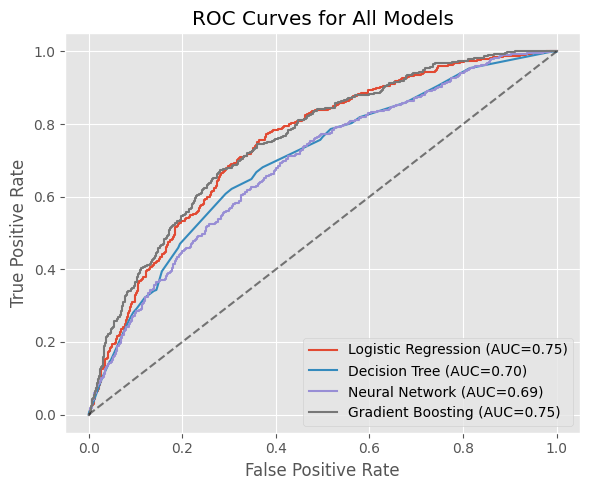

In [17]:
models = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'Neural Network': model_nn,
    'Gradient Boosting': model_gb
}
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    prob = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.2f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves for All Models')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Recommended Model

State which model you recommend and why. Show its confusion matrix at your chosen threshold.

C:\Users\madri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


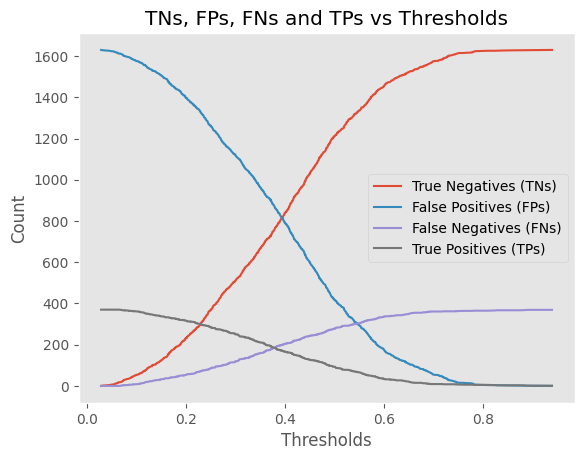

In [24]:
from sklearn.metrics import confusion_matrix_at_thresholds
y_score = model_gb.predict_proba(X_test)[:,1]
tns, fps, fns, tps, threshold = confusion_matrix_at_thresholds(y_test, y_score)
plt.plot(threshold, tns, label="True Negatives (TNs)")
plt.plot(threshold, fps, label="False Positives (FPs)")
plt.plot(threshold, fns, label="False Negatives (FNs)")
plt.plot(threshold, tps, label="True Positives (TPs)")
plt.xlabel("Thresholds")
plt.ylabel("Count")
plt.title("TNs, FPs, FNs and TPs vs Thresholds")
plt.legend()
plt.grid()

plt.show()

Text(0.5, 1.0, 'Confusion Matrix for Gradient Boosting')

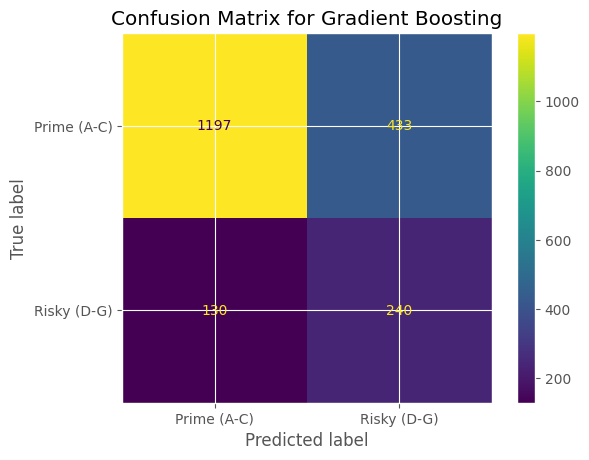

In [26]:
cm_gb = confusion_matrix(y_test, model_gb.predict(X_test_processed))
ConfusionMatrixDisplay(cm_gb, display_labels=['Prime (A-C)', 'Risky (D-G)']).plot()
plt.title('Confusion Matrix for Gradient Boosting')

## 9. Interpretation --- Top 5 Features

Rank the top 5 features for your recommended model. Use `feature_importances_` for tree/ensemble, scaled coefficients for logistic regression, or permutation importance for the neural network.

Add a one-sentence business interpretation per feature.

In [19]:
# TODO: top 5 feature importance / coefficient table
importances = model_gb.feature_importances_
df_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances 
})
df_importances = df_importances.sort_values(by='importance', ascending=False)
df_importances.head()

,feature,importance
26,credit_utilization,0.169580
18,total_debit_limit,0.162992
2,debt_to_income,0.114841
32,credit_history,0.110461
5,inquiries_last_12m,0.046945


The feature_importances_ score represents the normalized power each feature had in reducing impurity when it was chosen for tree splits. The sum across the array equals 1.0, and, in this case, the top 5 features account for ~60.5% of all impurity reduction. 

| Feature | Importance | Interpretation |
| --- | --- | --- |
| `credit_utilization` | 0.1696 | This captures how leveraged an applicant is as a percentage, adding valuable information about how leveraged the applicant is beyond the raw value. |
| `total_debit_limit` | 0.1630 | The debit limit could signal if the applicant has any premium bank accounts with higher debit limits, and estimate how liquid they are on any given day. |
| `debt_to_income` | 0.1148 | This standard feature informs the model (and company) about how leveraged an applicant currently is, and how much of their income (if any) is remaining to pay some back. |
| `credit_history` | 0.1105 | The credit history feature contextualizes the applicant's years of credit history, possibly signaling if the applicant is a brand new borrower. |
| `inquiries_last_12m` | 0.046945 | The volume of inquiries in the past year could signal an applicant who is rapidly increasing their debt, increasing their disapproval rates, or both. |